In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import expm
import matplotlib.colors as mcolors
from scipy.linalg import block_diag as blkdiag
import cvxpy as cp
from scipy.integrate import solve_ivp
from scipy import stats

plt.rcParams['font.sans-serif'] = 'Helvetica'

Transit time (hours),  6.931471805599452


/var/folders/wm/4kk2jlxx31d2z_19llvy_w240000gn/T/ipykernel_5812/127363778.py:97: RuntimeWarning: divide by zero encountered in divide
  plt.plot(-g/deltavec, deltavec, color='black', linewidth=2)
/var/folders/wm/4kk2jlxx31d2z_19llvy_w240000gn/T/ipykernel_5812/127363778.py:110: RuntimeWarning: divide by zero encountered in scalar divide
  ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{np.log(2)/x:.1f}"))


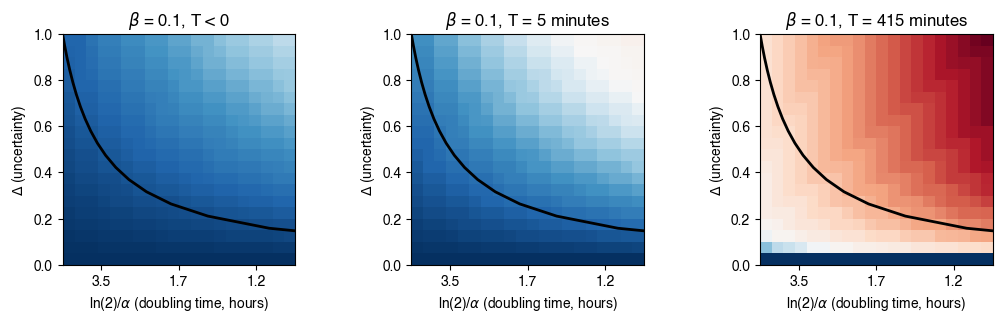

In [107]:
adsweepres = 20
kpsweepres = 20
allbeta = [0.1]
print('Transit time (hours), ',np.log(2)/allbeta[0])
allT = [-1.0,5/60,np.log(2)/allbeta[0]]
alphamax = 0.7
bsweepres = len(allbeta)
tsweepres= len(allT)
stabilityplot = np.zeros((adsweepres,adsweepres,bsweepres,tsweepres))
modelAsContinuous = 1
alphavec = np.linspace(0.1,alphamax,adsweepres)
deltavec = np.linspace(0,1.0,adsweepres)
tt=-1
Td = .1
g = -.1
for T in allT:
    tt+=1
    kk = -1
    for b in allbeta:
        kk += 1
        ii = -1
        for a in alphavec:
            ii += 1
            jj = -1
            for d in deltavec:
                jj +=1
                minmaxeig = 1e6
                A = [[a-a*b,0,0,a*b],
                     [0,g-b,b,0],
                     [0,b,g-b,0],
                     [a*b,0,0,a-a*b]]
                A = np.array(A)

                # define the states: x1, damp-error1,damp-error1-en-route, d2-enroute,d2,x2
                if not modelAsContinuous:
                    A = expm(np.array(A)*Td)
                
                for k in  np.linspace(0,1.0,kpsweepres):
                    for p in np.linspace(0,1,kpsweepres):
                        # K = [[-k,0,0,0], # without comms, intuitive 2d case for b = 0
                        #      [0,k*d,0,0],
                        #      [0,0,k*d,0],
                        #      [0,0,0,-k]] 
                        if T > 0: # comms are delayed
                            K = [[-k,0,0,-p*(d+T)],
                                 [1+k*d,k*d,p*(d+T),p*(d+T)],
                                 [p*(d+T),p*(d+T),k*d,1+k*d],
                                 [-p*(d+T),0,0,-k]] 
                            K = [[-k,0,0,-p*(d+T)],
                                 [k*d,k*(d+T),p*(d+T),p*(d+T)],
                                 [p*(d+T),p*(d+T),k*(d+T),k*d],
                                 [-p*(d+T),0,0,-k]] 
                            K = [[-k,0,0,-p*(d*T)],
                                 [k*d,k*(d*T),p*(d*T),p*(d*T)],
                                 [p*(d*T),p*(d*T),k*(d*T),k*d],
                                 [-p*(d*T),0,0,-k]] 
                            Te = T + Td

                        else: # only bottlenecked by uncertainty
                            K = [[-k,0,0,-p],
                                 [1+k*d,k*d,p*(d),p*d],
                                 [p*d,p*(d),k*d,1+k*d],
                                 [-p,0,0,-k]] 
                            Te = Td * 1.0
                        K = [[-k,0,0,-p*(d*Te)],
                             [k*d,k*(d*Te),p*(d*Te),p*(d*Te)],
                             [p*(d*Te),p*(d*Te),k*(d*Te),k*d],
                             [-p*(d*Te),0,0,-k]] 
                        K = np.array(K)

                        if modelAsContinuous:
                            maxeig = np.max(np.real(np.linalg.eigvals(A+K)))
                        else:
                            maxeig = np.max(np.abs(np.linalg.eigvals(A+K)))
                        if maxeig < minmaxeig:
                            minmaxeig = maxeig
                stabilityplot[ii,jj,kk,tt] = minmaxeig 

plt.figure(figsize=(len(allT)*4,len(allbeta)*3))

pltInd = 0
recolorBool = 0
if modelAsContinuous:
    norm = mcolors.TwoSlopeNorm(vmin=stabilityplot.min(), vcenter=0, vmax=stabilityplot.max())
else:
    norm = mcolors.TwoSlopeNorm(vmin=stabilityplot.min(), vcenter=1, vmax=stabilityplot.max())

for bb in range(len(allbeta)): 
    for tt in range(len(allT)):
        pltInd += 1
        plt.subplot(len(allbeta),len(allT),pltInd)
        # rescale image so that 0 to 1 is blue and 1 to 2 is red
        showthisarray = np.flipud(np.transpose(stabilityplot[:,:,bb,tt]))*1.0

        plt.imshow(showthisarray,cmap='RdBu_r',norm=norm,extent=[alphavec.min(), alphavec.max(), deltavec.min(), deltavec.max()],aspect='auto')
        # if allbeta[bb] == 0 and allT[tt]<0:
        plt.plot(-g/deltavec, deltavec, color='black', linewidth=2)
        
        if allT[tt] >= 0:
            plt.title(r'$\beta$ = ' + str(allbeta[bb]) + ', T = ' + str(int(allT[tt]*60)) + ' minutes')
        else:
            plt.title(r'$\beta$ = ' + str(allbeta[bb]) + ', T < 0')
        plt.ylabel(r'$\Delta$ (uncertainty)')
        plt.xlabel(r'ln(2)/$\alpha$ (doubling time, hours)')
        plt.clim((np.amin(stabilityplot),np.amax(stabilityplot)))
        # plt.colorbar()
        plt.xlim(alphavec.min(), alphavec.max())
        plt.ylim(deltavec.min(), deltavec.max()) 
        ax = plt.gca()
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{np.log(2)/x:.1f}"))
        plt.subplots_adjust(hspace=0., wspace=0.5)
        

Transit time (hours),  3.465735902799726


/var/folders/wm/4kk2jlxx31d2z_19llvy_w240000gn/T/ipykernel_5812/1365672256.py:63: RuntimeWarning: divide by zero encountered in divide
  plt.plot(-g/deltavec, deltavec, color='black', linewidth=2)


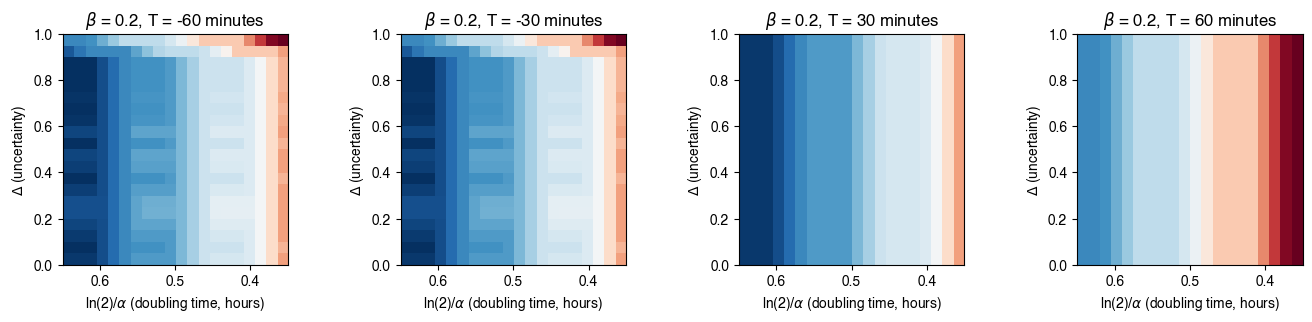

In [108]:
adsweepres = 20
kpsweepres = 20
allbeta = [0.2]
print('Transit time (hours), ',np.log(2)/allbeta[0])
allT = [-1.0,-.5,.5,1]
alphamax = 0.7
bsweepres = len(allbeta)
tsweepres= len(allT)
stabilityplot = np.zeros((adsweepres,adsweepres,bsweepres,tsweepres))
alphavec = np.linspace(0.1,alphamax,adsweepres)+1.0
deltavec = np.linspace(0,1.0,adsweepres)
tt=-1
Td = 1 #h
g = .1
for T in allT:
    tt+=1
    kk = -1
    for b in allbeta:
        kk += 1
        ii = -1
        for a in alphavec:
            ii += 1
            jj = -1
            for d in deltavec:
                jj +=1
                minmaxeig = 1e6
                for k in  np.linspace(0,2,kpsweepres):
                    for p in np.linspace(0,2,kpsweepres):
                        if T>0:                         
                            Te = T
                            Tlead = 0
                        else:
                            Te = 0
                            Tlead = 1

                        Ay = [[k+g,b+p*(d*Tlead+Te-1)],
                             [b+p*(d*Tlead+Te-1),k+g]]
                        Ax = [[a-k,b],
                             [b,a-k]]
                        Ay = np.array(Ay)
                        Ax = np.array(Ax)
                        Acl = blkdiag(Ax,Ay)

                        maxeig = np.max(np.abs(np.linalg.eigvals(Acl)))
                        if maxeig < minmaxeig:
                            minmaxeig = maxeig
                stabilityplot[ii,jj,kk,tt] = minmaxeig 

plt.figure(figsize=(len(allT)*4,len(allbeta)*3))

pltInd = 0
recolorBool = 0
norm = mcolors.TwoSlopeNorm(vmin=stabilityplot.min(), vcenter=1, vmax=stabilityplot.max())

for bb in range(len(allbeta)): 
    for tt in range(len(allT)):
        pltInd += 1
        plt.subplot(len(allbeta),len(allT),pltInd)
        # rescale image so that 0 to 1 is blue and 1 to 2 is red
        showthisarray = np.flipud(np.transpose(stabilityplot[:,:,bb,tt]))*1.0
        plt.imshow(showthisarray,cmap='RdBu_r',norm=norm,extent=[alphavec.min(), alphavec.max(), deltavec.min(), deltavec.max()],aspect='auto')
        # if allbeta[bb] == 0 and allT[tt]<0:
        plt.plot(-g/deltavec, deltavec, color='black', linewidth=2)
        
        plt.title(r'$\beta$ = ' + str(allbeta[bb]) + ', T = ' + str(int(allT[tt]*60)) + ' minutes')
            
        plt.ylabel(r'$\Delta$ (uncertainty)')
        plt.xlabel(r'ln(2)/$\alpha$ (doubling time, hours)')
        plt.clim((np.amin(stabilityplot),np.amax(stabilityplot)))
        # plt.colorbar()
        plt.xlim(alphavec.min(), alphavec.max())
        plt.ylim(deltavec.min(), deltavec.max()) 
        ax = plt.gca()
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{np.log(2)/x:.1f}"))
        plt.subplots_adjust(hspace=0., wspace=0.5)
        

-0.1
0.31666666666666665


/var/folders/wm/4kk2jlxx31d2z_19llvy_w240000gn/T/ipykernel_6515/181839675.py:91: RuntimeWarning: divide by zero encountered in divide
  plt.plot(g/deltavec, deltavec, color='black', linewidth=2)
/var/folders/wm/4kk2jlxx31d2z_19llvy_w240000gn/T/ipykernel_6515/181839675.py:104: RuntimeWarning: divide by zero encountered in scalar divide
  ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{np.log(2)/x:.1f}"))


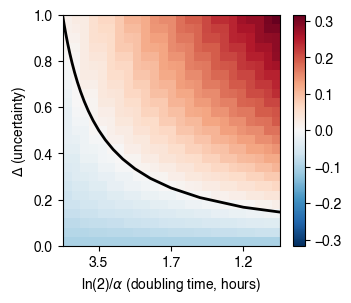

In [9]:
adsweepres = 25
kpsweepres = 25
allbeta = [0.0]
allT = [-1.0]
alphamax = 0.7
bsweepres = len(allbeta)
tsweepres= len(allT)
stabilityplot = np.zeros((adsweepres,adsweepres,bsweepres,tsweepres))
modelAsContinuous = 1
alphavec = np.linspace(0.1,alphamax,adsweepres)
deltavec = np.linspace(0,1.0,adsweepres)
tt=-1
Td = .1
g = .1
for T in allT:
    tt+=1
    kk = -1
    for b in allbeta:
        kk += 1
        ii = -1
        for a in alphavec:
            ii += 1
            jj = -1
            for d in deltavec:
                jj +=1
                minmaxeig = 1e6
                A = [[a-a*b,0,0,a*b],
                     [0,g-b,b,0],
                     [0,b,g-b,0],
                     [a*b,0,0,a-a*b]]
                A = np.array(A)

                # define the states: x1, damp-error1,damp-error1-en-route, d2-enroute,d2,x2
                if not modelAsContinuous:
                    A = expm(np.array(A)*Td)
                
                for k in  np.linspace(0,1.0,kpsweepres):
                    for p in np.linspace(0,1.0,kpsweepres):
                        # K = [[-k,0,0,0], # without comms, intuitive 2d case for b = 0
                        #      [0,k*d,0,0],
                        #      [0,0,k*d,0],
                        #      [0,0,0,-k]] 
                        if T > 0: # comms are delayed
                            K = [[-k,0,0,-p*(d+T)],
                                 [1+k*d,k*d,p*(d+T),p*(d+T)],
                                 [p*(d+T),p*(d+T),k*d,1+k*d],
                                 [-p*(d+T),0,0,-k]] 
                            K = [[-k,0,0,-p*(d+T)],
                                 [k*d,k*(d+T),p*(d+T),p*(d+T)],
                                 [p*(d+T),p*(d+T),k*(d+T),k*d],
                                 [-p*(d+T),0,0,-k]] 
                            K = [[-k,0,0,-p*(d*T)],
                                 [k*d,k*(d*T),p*(d*T),p*(d*T)],
                                 [p*(d*T),p*(d*T),k*(d*T),k*d],
                                 [-p*(d*T),0,0,-k]] 
                            Te = T + Td

                        else: # only bottlenecked by uncertainty
                            K = [[-k,0,0,-p],
                                 [1+k*d,k*d,p*(d),p*d],
                                 [p*d,p*(d),k*d,1+k*d],
                                 [-p,0,0,-k]] 
                            Te = Td * 1.0
                        K = np.array(K)
                        Ax = np.array(a-k)
                        Ay = (k*d-g)
                        Acl = blkdiag(Ax,Ay)
                        maxeig = np.max(np.real(np.linalg.eigvals(Acl)))
                        if maxeig < minmaxeig:
                            minmaxeig = maxeig
                stabilityplot[ii,jj,kk,tt] = minmaxeig 

plt.figure(figsize=(len(allT)*3.5,len(allbeta)*3))

pltInd = 0
recolorBool = 0
print(stabilityplot.min())
print(stabilityplot.max())

norm = mcolors.TwoSlopeNorm(vmin=-np.abs(stabilityplot).max(), vcenter=0, vmax=np.abs(stabilityplot.max()))

for bb in range(len(allbeta)): 
    for tt in range(len(allT)):
        pltInd += 1
        plt.subplot(len(allbeta),len(allT),pltInd)
        # rescale image so that 0 to 1 is blue and 1 to 2 is red
        showthisarray = np.flipud(np.transpose(stabilityplot[:,:,bb,tt]))*1.0

        plt.imshow(showthisarray,cmap='RdBu_r',norm=norm,extent=[alphavec.min(), alphavec.max(), deltavec.min(), deltavec.max()],aspect='auto')
        # if allbeta[bb] == 0 and allT[tt]<0:
        plt.plot(g/deltavec, deltavec, color='black', linewidth=2)
        
        # if allT[tt] >= 0:
            # plt.title(r'$\beta$ = ' + str(allbeta[bb]) + ', T = ' + str(int(allT[tt]*60)) + ' minutes')
        # else:
            # plt.title(r'$\beta$ = ' + str(allbeta[bb]) + ', T < 0')
        plt.ylabel(r'$\Delta$ (uncertainty)')
        plt.xlabel(r'ln(2)/$\alpha$ (doubling time, hours)')
        plt.clim(-np.abs(stabilityplot).max(),np.abs(stabilityplot).max())
        plt.colorbar()
        plt.xlim(alphavec.min(), alphavec.max())
        plt.ylim(deltavec.min(), deltavec.max()) 
        ax = plt.gca()
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{np.log(2)/x:.1f}"))
        plt.subplots_adjust(hspace=0., wspace=0.5)

In [77]:

allcol = ["#185FA5","#D85A30","#1D9E75","#BA7517","#888780",'red']

def simulate(a,k,T):
    # def simFxn(t,x,a,k):
        # return (a-k)*x+np.random.randn()
    # solution = solve_ivp(simFxn,[0,T],[0],method='RK45',dense_output=True,args=(a,k))
    # x = solution.y
    x=np.zeros(T)
    
    wlevel = 0.1
    vlevel = 0.1
    x[0] = np.random.randn()*wlevel
    for tt in range(1,T):
        x[tt] = a*x[tt-1]+np.random.randn()*wlevel-k*(x[tt-1]+np.random.randn()*wlevel)
    return x + np.random.randn(T)*vlevel
nIter = 1000
T = 50
sampleThese =np.linspace(2,T,T-2+1).astype(int)
acl = 0.1
alld = [0.0,0.0,0.0]
alla = [acl,acl+1.0,acl+2.0]
polytopeVol = np.zeros(len(alla))
g = .0999
cx=np.zeros((nIter,len(sampleThese),len(alld)))
for ii in range(nIter):
    for dd in range(len(alld)):
        d = alld[dd]
        true_a = alla[dd]
        true_k = true_a-acl
        x = simulate(true_a,true_k,T)
        kvar = cp.Variable()
        avar = cp.Variable()
        arange = 1e6
        # constraints = [kvar*d+g <= 1,avar<=true_a+(arange/2),avar>=true_a-(arange/2),kvar>=0,avar-kvar<=1,avar-kvar>=-1]
        constraints = [kvar*d+g <= 1,avar-kvar<=1,avar-kvar>=-1]
        if d == 0:
            polytopeVol[dd] = np.inf
        else:
            krange = (1-g)/d-(true_a+arange/2-1.0)
            polytopeVol[dd] = np.round(arange*krange,2)
        for nn in range(len(sampleThese)):
            N = sampleThese[nn]
            cost = cp.sum_squares((avar-kvar) * x[1:N]-x[:N-1])/N
            prob = cp.Problem(cp.Minimize(cost),constraints)
            prob.solve(solver=cp.SCS, eps=1e-6)
            if kvar.value:
                cx[ii,nn,dd] = np.abs(true_k-kvar.value)
                cx[ii,nn,dd] = np.abs(avar.value-kvar.value-acl)

            else:
                cx[ii,nn,dd] = np.nan

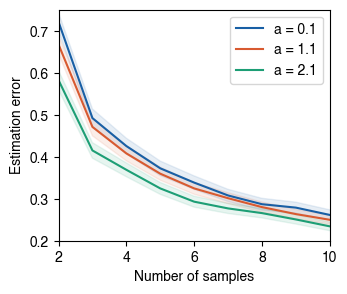

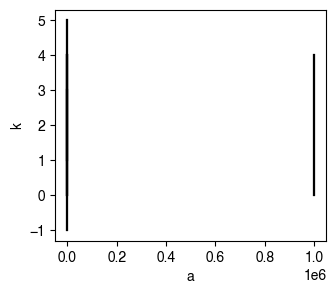

In [84]:

plt.figure(figsize=(3.5,3))

for dd in range(len(alld)):
    se = np.nanstd(cx[:,:,dd],axis=0)
    se = np.array([x/np.sqrt(nIter) for x,y in zip(se,sampleThese)])
    plt.fill_between(sampleThese,np.squeeze(np.nanmean(cx[:,:,dd],axis=0)) - 1.96*se, np.squeeze(np.nanmean(cx[:,:,dd],axis=0)) + 1.96*se, color=allcol[dd],alpha=0.1,label='_')
for dd in range(len(alld)):
    
    lbl = 'a = ' + str(alla[dd]) + ', $\Delta$ = ' + str(alld[dd]) + ', SetVol = ' + str(polytopeVol[dd])
    # lbl = '$\Delta$ = ' + str(alld[dd])
    lbl = 'a = ' + str(alla[dd])

    plt.plot(sampleThese,np.squeeze(np.nanmean(cx[:,:,dd],axis=0)),color=allcol[dd],label=lbl)

sigtest = np.zeros((np.shape(cx)[1]))
for tt in range(np.shape(cx)[1]):
    p = (stats.ttest_ind(cx[:,tt,0],cx[:,tt,1]))
    if p.pvalue < .05:
        sigtest[tt] = 1
    else:
        sigtest[tt] = np.nan

# plt.plot(sampleThese,sigtest* .7,'k--',linewidth = .5,label = 'p < .05') 


plt.ylim((0.2,0.75))
plt.xlim((2,10))
plt.xlabel('Number of samples')
plt.ylabel('Estimation error')

plt.legend()

plt.figure(figsize=(3.5,3))

for dd in range(len(alld)):
    kplot = np.linspace(0,4,300)
    aplot = np.linspace(0,4,300)
    d = alld[dd]
    plt.plot(aplot,aplot-1.0,color='k') # a-k=1
    plt.plot(aplot,aplot+1.0,color='k') # a-k=-1
    plt.plot(aplot*0,kplot,color='k')
    plt.plot(aplot*0+1.0,kplot,color='k')
    plt.plot(aplot*0+alla[dd]+arange-(alla[dd]-1.0),kplot,color='k')
    plt.plot(aplot,aplot*0,color='k')
    if d>0:
        plt.plot(aplot,aplot*0+(1-g)/d,color=allcol[dd])

plt.xlabel('a')
plt.ylabel('k')
# plt.xlim((0.95,1.55))
# plt.ylim((-0.05,2.55))

plt.savefig('polytope.eps')